<a href="https://colab.research.google.com/github/freddyinocente/entrega-1/blob/main/entrega1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importar datos

In [418]:
#Importar librerías
import geopandas as gpd
import pandas as pd

#Cargar GeoDataFrame del mapa mundial
linkGit = 'https://github.com/freddyinocente/entrega-1/raw/main/'
linkWorldMaps = 'worldMaps.gpkg'
countries = gpd.read_file(linkGit + linkWorldMaps, layer='countries')

#Cargar DataFrame con los datos tabulares
someDataLink = 'some_dataworld.csv'
someData = pd.read_csv(linkGit + someDataLink)

#Inspeccionar la estructura inicial
someData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       171 non-null    object 
 1   iso2          170 non-null    object 
 2   iso3          171 non-null    object 
 3   region        171 non-null    object 
 4   fragility     171 non-null    float64
 5   co2           171 non-null    int64  
 6   sq_km         171 non-null    int64  
 7   num_airports  171 non-null    int64  
 8   population    171 non-null    int64  
 9   mobiles       171 non-null    int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 13.5+ KB


Estandarización de nombres

In [419]:
#Uniformizar la columna a Country
countries.rename(columns={'COUNTRY': 'Country'}, inplace=True)

#Convertir ambas columnas a mayúsculas
countries['Country'] = countries.Country.str.upper()


In [420]:
onlyDF=set(someData.Country)- set(countries.Country)
onlyGDF=set(countries.Country)- set(someData.Country)
#para verificar que países no coinciden

In [421]:
#instalar la librería thefuzz para emparejamiento de texto
!pip install thefuzz
from thefuzz.process import extractOne as best

#correcciones para países con denominación ambigua
manualChanges = {
    'SWAZILAND': 'ESWATINI',
    'LAOS': "LAO PEOPLE'S DEMOCRATIC REPUBLIC (THE)",
    'SOUTH KOREA': 'KOREA (THE REPUBLIC OF)',
}
countries.replace(to_replace={'Country': manualChanges}, inplace=True)

#Recalcular diferencias
onlyDF = set(someData.Country) - set(countries.Country)
onlyGDF = set(countries.Country) - set(someData.Country)

# Emparejamiento por coincidencia aproximada
changesToDF = {country: best(country, onlyGDF)[0] for country in onlyDF}
someData.replace(to_replace={'Country': changesToDF}, inplace=True)

#Ejecutar la unión espacial
theMapAndData = countries.merge(someData, on='Country')
theMapAndData.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 171 entries, 0 to 170
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Country       171 non-null    object  
 1   geometry      171 non-null    geometry
 2   iso2          170 non-null    object  
 3   iso3          171 non-null    object  
 4   region        171 non-null    object  
 5   fragility     171 non-null    float64 
 6   co2           171 non-null    int64   
 7   sq_km         171 non-null    int64   
 8   num_airports  171 non-null    int64   
 9   population    171 non-null    int64   
 10  mobiles       171 non-null    int64   
dtypes: float64(1), geometry(1), int64(5), object(4)
memory usage: 14.8+ KB


In [422]:

theMapAndData.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 171 entries, 0 to 170
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Country       171 non-null    object  
 1   geometry      171 non-null    geometry
 2   iso2          170 non-null    object  
 3   iso3          171 non-null    object  
 4   region        171 non-null    object  
 5   fragility     171 non-null    float64 
 6   co2           171 non-null    int64   
 7   sq_km         171 non-null    int64   
 8   num_airports  171 non-null    int64   
 9   population    171 non-null    int64   
 10  mobiles       171 non-null    int64   
dtypes: float64(1), geometry(1), int64(5), object(4)
memory usage: 14.8+ KB


In [423]:
theMapAndData

,Country,geometry,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,mobiles
0,ANTIGUA AND BARBUDA,"MULTIPOLYGON (((-61.73889 17.54055, -61.75195 ...",AG,ATG,CENTRAL AMERICA AND THE CARIBBEAN,54.4,729000,443,4,102634,184000
1,AFGHANISTAN,"MULTIPOLYGON (((61.27656 35.60725, 61.29638 35...",AF,AFG,SOUTH ASIA,105.0,7893000,652230,68,40121552,23000000
2,ALGERIA,"MULTIPOLYGON (((-5.15213 30.18047, -5.13917 30...",DZ,DZA,AFRICA,75.4,151633000,2381740,95,47022473,51500000
3,AZERBAIJAN,"MULTIPOLYGON (((46.54037 38.87559, 46.49554 38...",AZ,AZE,MIDDLE EAST,73.2,35389000,86600,32,10650239,11000000
4,ALBANIA,"MULTIPOLYGON (((20.79192 40.43154, 20.78722 40...",AL,ALB,EUROPE,58.9,3794000,28748,3,3107100,2610000
...,...,...,...,...,...,...,...,...,...,...,...
166,ZAMBIA,"MULTIPOLYGON (((30.21302 -14.98172, 30.21917 -...",ZM,ZMB,AFRICA,85.7,6798000,752618,120,20799116,21200000
167,ZIMBABWE,"MULTIPOLYGON (((32.48888 -21.34445, 32.46541 -...",ZW,ZWE,AFRICA,99.5,7902000,390757,144,17150352,15000000
168,SOUTH SUDAN,"MULTIPOLYGON (((34.21807 9.96458, 34.20722 9.9...",SS,SSD,AFRICA,112.2,1778000,644329,89,12703714,6170000
169,INDONESIA,"MULTIPOLYGON (((123.21846 -10.80917, 123.19832...",ID,IDN,EAST AND SOUTHEAST ASIA,70.4,563543000,1904569,556,281562465,352000000


In [424]:
theMapAndData.to_file("worldindicators.json")

In [425]:
theMapAndData.region.value_counts()

,count
region,
AFRICA,51
EUROPE,37
MIDDLE EAST,16
CENTRAL AMERICA AND THE CARIBBEAN,16
EAST AND SOUTHEAST ASIA,15
SOUTH AMERICA,12
SOUTH ASIA,8
AUSTRALIA AND OCEANIA,7
CENTRAL ASIA,6


Mapa de América

<Axes: >

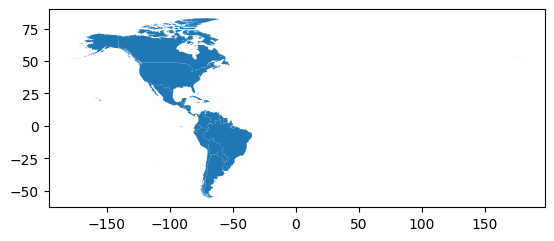

In [426]:
#definir las regiones
regiones_america = [
    'NORTH AMERICA',
    'SOUTH AMERICA',
    'CENTRAL AMERICA AND THE CARIBBEAN'
]

#filtrar el mapa usando esa lista
america = theMapAndData[theMapAndData.region.isin(regiones_america)]

# dibujar el mapa
america.plot()

Asignación de mobiles

In [427]:
justDots=america.copy()
dot_value = 1000000
justDots['num_dots'] = (justDots['mobiles'] / dot_value).astype(int)

In [428]:
justDots

,Country,geometry,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,mobiles,num_dots
0,ANTIGUA AND BARBUDA,"MULTIPOLYGON (((-61.73889 17.54055, -61.75195 ...",AG,ATG,CENTRAL AMERICA AND THE CARIBBEAN,54.4,729000,443,4,102634,184000,0
7,ARGENTINA,"MULTIPOLYGON (((-71.01648 -36.47591, -70.98195...",AR,ARG,SOUTH AMERICA,46.0,193205000,2780400,764,46994384,62700000,62
11,BARBADOS,"MULTIPOLYGON (((-59.53306 13.05055, -59.54542 ...",BB,BRB,CENTRAL AMERICA AND THE CARIBBEAN,48.0,1703000,430,1,304139,323000,0
14,BAHAMAS,"MULTIPOLYGON (((-77.95029 26.89778, -77.91695 ...",BS,BHS,CENTRAL AMERICA AND THE CARIBBEAN,48.8,3984000,13880,54,410862,400000,0
16,BELIZE,"MULTIPOLYGON (((-88.28914 17.1225, -88.28001 1...",BZ,BLZ,CENTRAL AMERICA AND THE CARIBBEAN,62.5,541000,22966,27,415789,264000,0
18,BOLIVIA,"MULTIPOLYGON (((-62.19884 -20.47139, -62.26945...",BO,BOL,SOUTH AMERICA,72.9,17786000,1098581,201,12311974,12000000,12
22,BRAZIL,"MULTIPOLYGON (((-70.62862 -9.94849, -70.62889 ...",BR,BRA,SOUTH AMERICA,71.8,456670000,8515770,5297,220051512,213000000,213
27,CANADA,"MULTIPOLYGON (((-84.47945 77.29443, -84.46764 ...",CA,CAN,NORTH AMERICA,20.0,612084000,9984670,1459,38794813,36500000,36
34,CHILE,"MULTIPOLYGON (((-73.61806 -51.6339, -73.60494 ...",CL,CHL,SOUTH AMERICA,38.9,88333000,756102,379,18664652,26700000,26
37,COLOMBIA,"MULTIPOLYGON (((-81.71306 12.49028, -81.72014 ...",CO,COL,SOUTH AMERICA,75.7,81007000,1138910,661,49588357,87400000,87


In [429]:
justDots = justDots.sample_points(size=justDots['num_dots']).explode(index_parts=True)

In [430]:
justDots

7    0     POINT (-63.24914 -31.67536)
     1     POINT (-72.18566 -50.95618)
     2     POINT (-58.34267 -37.52047)
     3     POINT (-65.87188 -33.31109)
     4     POINT (-62.79756 -34.28199)
                      ...             
160  13      POINT (-61.84232 4.60407)
     14      POINT (-73.30207 9.26875)
     15      POINT (-62.61193 9.05491)
     16      POINT (-63.84703 6.35531)
     17      POINT (-65.36999 9.23874)
Name: sampled_points, Length: 1138, dtype: geometry

In [431]:
type(justDots)

geopandas.geoseries.GeoSeries

In [432]:
justDots.reset_index(drop=True, inplace=True)
america_dots=gpd.GeoDataFrame(geometry=justDots)
america_dots

,geometry
0,POINT (-63.24914 -31.67536)
1,POINT (-72.18566 -50.95618)
2,POINT (-58.34267 -37.52047)
3,POINT (-65.87188 -33.31109)
4,POINT (-62.79756 -34.28199)
...,...
1133,POINT (-61.84232 4.60407)
1134,POINT (-73.30207 9.26875)
1135,POINT (-62.61193 9.05491)
1136,POINT (-63.84703 6.35531)


In [433]:
america_dots.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1138 entries, 0 to 1137
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   geometry  1138 non-null   geometry
dtypes: geometry(1)
memory usage: 9.0 KB


Dot density map

<Axes: >

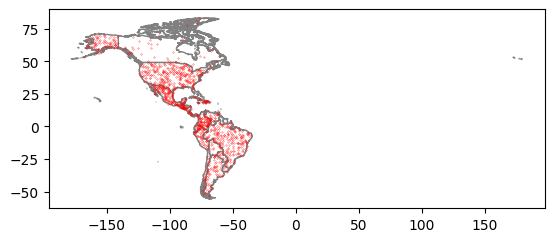

In [434]:
base=america.plot(facecolor="white",
               edgecolor='grey')
america_dots.plot(markersize=0.05, color='red',ax=base)

<Axes: >

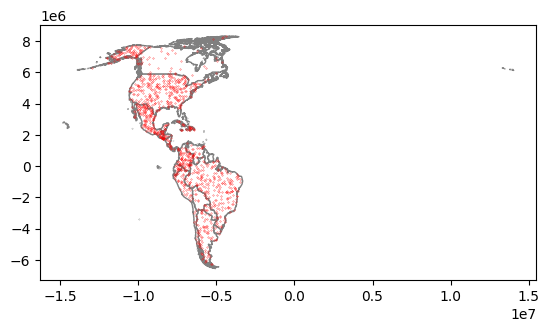

In [435]:
base=america.to_crs(8857).plot(facecolor="white",
                              edgecolor='grey')
america_dots.to_crs(8857).plot(markersize=0.05, color='red',ax=base)

In [436]:
america_8857=america.to_crs(8857)
america_dots_8857=america_dots.to_crs(8857)

#Proportional Symbol Map

In [437]:
america_8857_centroids = america_8857.copy()
america_8857_centroids['geometry'] = america_8857_centroids['geometry'].centroid

In [438]:
america_8857_centroids['size'] = america_8857_centroids['mobiles'].apply(lambda x: x**0.5/100)

<Axes: >

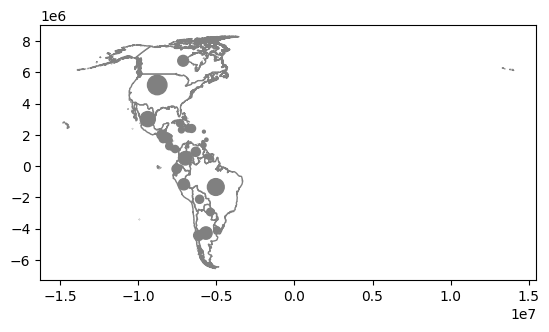

In [439]:
base=america_8857.plot(facecolor="white",
                      edgecolor='grey')
america_8857_centroids.plot(
    ax=base,
    markersize=america_8857_centroids['size'],
    color='grey'
)

Mapa coropleto

<Axes: >

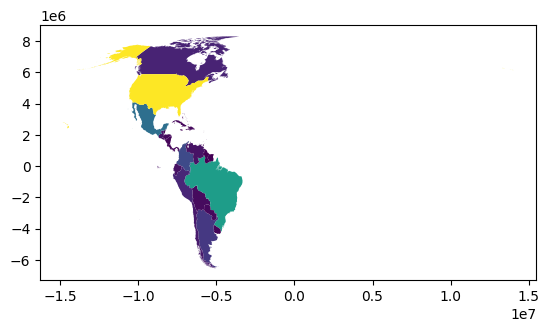

In [440]:
america_8857.plot(america_8857.mobiles)

<Axes: >

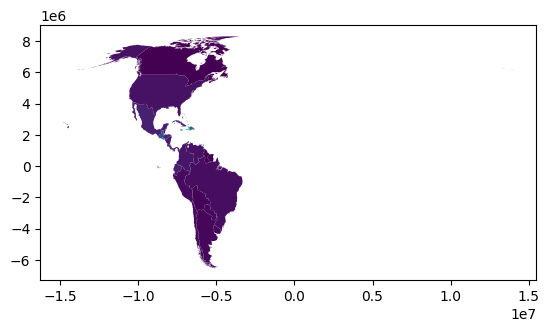

In [441]:
america_8857.plot(america_8857.population/america_8857.sq_km)

Discretización

In [442]:
! pip show numba mapclassify numpy

Name: numba
Version: 0.61.2
Summary: compiling Python code using LLVM
Home-page: https://numba.pydata.org
Author: 
Author-email: 
License: BSD
Location: /usr/local/lib/python3.13/dist-packages
Requires: llvmlite, numpy
Required-by: librosa, pynndescent, pytensor, quantecon, segregation, shap, stumpy, umap-learn
---
Name: mapclassify
Version: 2.10.0
Summary: Classification Schemes for Choropleth Maps.
Home-page: 
Author: 
Author-email: 
License: BSD 3-Clause
Location: /usr/local/lib/python3.13/dist-packages
Requires: networkx, numpy, pandas, scikit-learn, scipy
Required-by: giddy, pysal, segregation, splot, spopt
---
Name: numpy
Version: 2.1.3
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License: Copyright (c) 2005-2024, NumPy Developers.
 All rights reserved.

 Redistribution and use in source and binary forms, with or without
 modification, are permitted provided that the following conditions a

In [443]:
america_8857['mobiles']=america_8857.mobiles/america_8857.sq_km

In [444]:
import mapclassify
import numpy as np

america_8857['mobiles_density'] = america_8857['mobiles'] / america_8857['sq_km']

np.random.seed(12345)

K = 5
theVar = america_8857['mobiles_density']

ei5 = mapclassify.EqualInterval(theVar, k=K)
msd = mapclassify.StdMean(theVar)
q5 = mapclassify.Quantiles(theVar, k=K)

mb5 = mapclassify.MaximumBreaks(theVar, k=K)
ht = mapclassify.HeadTailBreaks(theVar)
fj5 = mapclassify.FisherJenks(theVar, k=K)
jc5 = mapclassify.JenksCaspall(theVar, k=K)
mp5 = mapclassify.MaxP(theVar, k=K)

In [445]:
class5 = ei5,msd, q5,mb5,  ht, fj5, jc5, mp5
fits = np.array([ c.adcm for c in class5])
adcms = pd.DataFrame(fits)
adcms['classifier'] = [c.name for c in class5]
adcms.columns = ['ADCM', 'Classifier']

<Axes: ylabel='Classifier'>

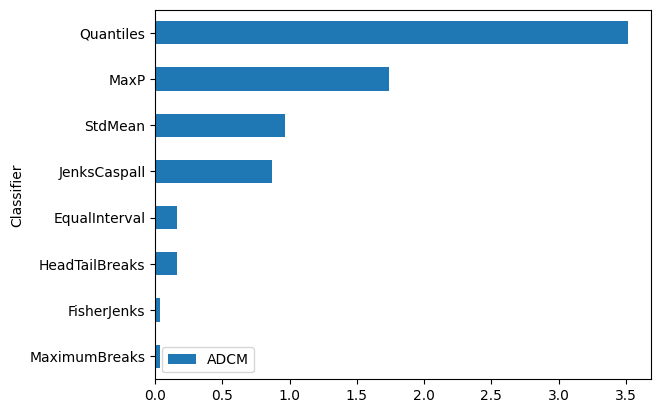

In [446]:
adcms.sort_values('ADCM').plot.barh(x='Classifier')

In [447]:
america_8857['mobiles_density_FJ5'] = fj5.yb

In [448]:
america_8857[['mobiles_density','mobiles_density_FJ5']].head(20)

,mobiles_density,mobiles_density_FJ5
0,9.375844e-01,3
7,8.110600e-06,0
11,1.746890e+00,4
14,2.076257e-03,0
16,5.005336e-04,0
18,9.942992e-06,0
22,2.937188e-06,0
27,3.661217e-07,0
34,4.670361e-05,0
37,6.738025e-05,0


In [449]:
newLabelsForLevels={0:"0_VeryLow", 1:"1_Low", 2:"2_Middle", 3:"3_High", 4:"4_VeryHigh"}
america_8857['mobiles_density_FJ5_cat']=america_8857.loc[:,'mobiles_density_FJ5'].replace(newLabelsForLevels)
america_8857[['mobiles_density','mobiles_density_FJ5','mobiles_density_FJ5_cat']].head(20)

,mobiles_density,mobiles_density_FJ5,mobiles_density_FJ5_cat
0,9.375844e-01,3,3_High
7,8.110600e-06,0,0_VeryLow
11,1.746890e+00,4,4_VeryHigh
14,2.076257e-03,0,0_VeryLow
16,5.005336e-04,0,0_VeryLow
18,9.942992e-06,0,0_VeryLow
22,2.937188e-06,0,0_VeryLow
27,3.661217e-07,0,0_VeryLow
34,4.670361e-05,0,0_VeryLow
37,6.738025e-05,0,0_VeryLow


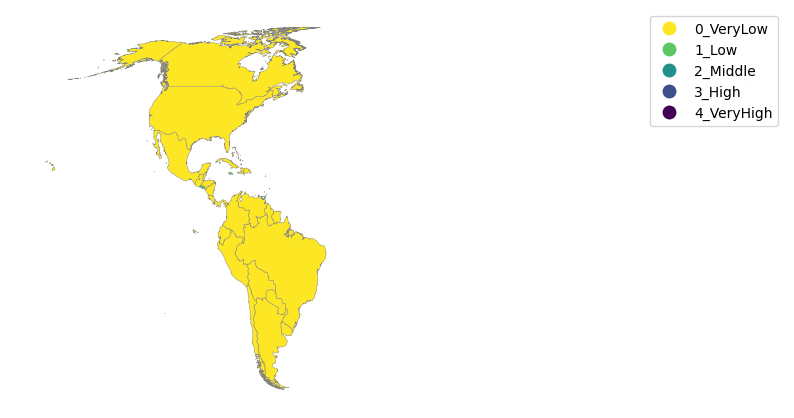

In [450]:
import matplotlib.pyplot as plt

f, ax = plt.subplots(1, figsize=(10, 10))
america_8857.plot(column='mobiles_density_FJ5_cat',
                 cmap='viridis_r',
                 categorical=True,
                 edgecolor='grey',
                 linewidth=0.3,
                 legend=True,
                 ax=ax
       )

ax.set_axis_off()

In [451]:
geodataframe_list = [var for var in globals() if isinstance(globals()[var], gpd.GeoDataFrame)]

print("List of GeoDataFrames in memory:")
for name in geodataframe_list:
    print(name)

List of GeoDataFrames in memory:
countries
_1
_4
_27
theMapAndData
america
_66
_68
_74
_80
_95
_100
america_dots
_104
america_8857
america_dots_8857
america_8857_centroids
_120
_125
_129
_141
_145
_176
_180
_216
_238
_243
_262
_266
_291
_296
_300
_323
_328
_332
_369
_387
_392
_396
_423
_428
_432
